In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import os
import glob
import torch
import pycolmap
import numpy as np
from demo_utils import *
from pathlib import Path

device = 'cuda' if torch.cuda.is_available() else 'cpu'
max_kpts = 2048

detector = "aliked"

from matcher.mnn import MNN
matcher = MNN(min_score=0.5, ratio_test=0.98)

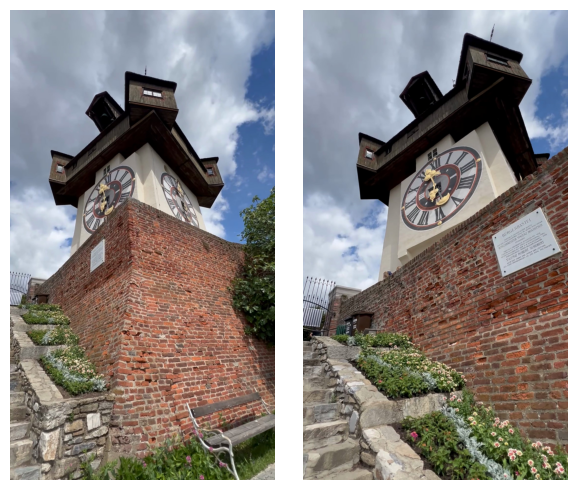

Image A shape: torch.Size([3, 3840, 2160]), Image B shape: torch.Size([3, 3840, 2160])


In [3]:
## load images
down_scaling_factor = 1
scene = "graz_clocktower" 

base_path = Path('assets') / scene
full_paths = sorted(glob.glob(f'{base_path}/**/*.jpg', recursive=True))
im_A_path, im_B_path = sorted([os.path.relpath(p, base_path) for p in full_paths])
img_A = load_image(str(base_path / im_A_path))
img_B = load_image(str(base_path / im_B_path))

plot_imgs([img_A, img_B])
print(f'Image A shape: {img_A.shape}, Image B shape: {img_B.shape}')

In [4]:
out = torch.load(f'assets/{scene}/{detector}_kpts.pth', weights_only=False)
F_gt = out['F_gt']
K_A = out['K_A']
K_B = out['K_B']
P = out['P'] # from COLMAP reconstruction

kpts1, des1 = out['kpts1'].to(device), out['desc1'].to(device)
kpts2, des2 = out['kpts2'].to(device), out['desc2'].to(device)
print(kpts1.shape, des1.shape, kpts2.shape, des2.shape)

matches = matcher.match([des1], [des2])[0].matches
kpts1_matched = kpts1[matches[:, 0]].cpu().numpy()
kpts2_matched = kpts2[matches[:, 1]].cpu().numpy()
print("matched:", kpts1_matched.shape, kpts2_matched.shape)
torch.cuda.empty_cache()

torch.Size([2037, 2]) torch.Size([2037, 128]) torch.Size([2041, 2]) torch.Size([2041, 128])
matched: (454, 2) (454, 2)


Reprojection error threshold: 5 pixels
Inliers: 20/22


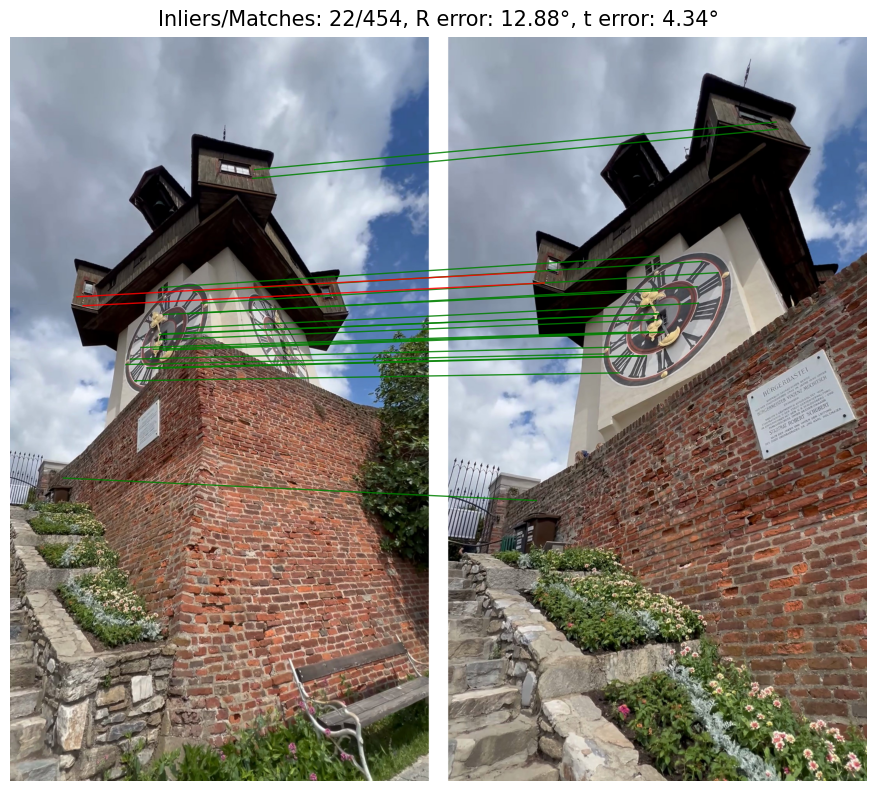

In [5]:
norm_threshold = 0.5 / (np.mean(np.abs(K_A[:2, :2])) + np.mean(np.abs(K_B[:2, :2])))
R_est, t_est, mask = estimate_pose(
    kpts1_matched, kpts2_matched,
    K_A, K_B, norm_threshold
)

pose_err = compute_pose_error(P, R_est, t_est)
plot_imgs_and_kpts(img_A.permute(1, 2, 0).cpu().numpy()*255, img_B.permute(1, 2, 0).cpu().numpy()*255, 
                kpts1_matched[mask], kpts2_matched[mask], # keeping only geometrically verified matches
                scatter=False, F_gt=F_gt, reth=5, figsize=(15, 8),
                highlight_bad_matches=False, 
                text=f'Inliers/Matches: {len(kpts1_matched[mask])}/{len(kpts1_matched)}, R error: {pose_err[0]:.2f}°, t error: {pose_err[1]:.2f}°',
                text_font=15)

In [6]:
# detector_dict = {
#     'kpts1': kpts1.detach().cpu(),
#     'kpts2': kpts2.detach().cpu(),
#     'desc1': des1.detach().cpu(),
#     'desc2': des2.detach().cpu(),
#     "K_A": K_A,
#     "K_B": K_B,
#     "P": P,
#     "F_gt": F_gt
# }
# torch.save(detector_dict, f'assets/{scene}/{detector}_kpts.pth')

### Extraction with SANDesc

In [7]:
path = f"pretrained/{detector}/final_MD.pth"
weights = torch.load(path,  map_location=device, weights_only=False)
config = weights['config']
model_config = {'ch_in': config['model_config']['unet_ch_in'],
                'kernel_size': config['model_config']['unet_kernel_size'],
                'activ': config['model_config']['unet_activ'],
                'norm': config['model_config']['unet_norm'],
                'skip_connection': config['model_config']['unet_with_skip_connections'],
                'spatial_attention': config['model_config']['unet_spatial_attention'],
                'third_block': config['model_config']['third_block'],
                }

from model.network_descriptor import SANDesc
sandesc = SANDesc(**model_config).eval().to(device)
sandesc.load_state_dict(weights['state_dict'])

<All keys matched successfully>

In [8]:
# sample kpts from desc volumes
from utils.utils_2D import grid_sample_nan

with torch.no_grad():
    desc_vol1 = sandesc(img_A[None].to(device))
    desc_vol2 = sandesc(img_B[None].to(device))

    des1 = grid_sample_nan(kpts1[None], desc_vol1, mode="nearest")[0][0].T
    des2 = grid_sample_nan(kpts2[None], desc_vol2, mode="nearest")[0][0].T

torch.cuda.empty_cache()

kpts1.shape, des1.shape, kpts2.shape, des2.shape

(torch.Size([2037, 2]),
 torch.Size([2037, 128]),
 torch.Size([2041, 2]),
 torch.Size([2041, 128]))

In [9]:
matches = matcher.match([des1], [des2])[0].matches
kpts1_matched = kpts1[matches[:, 0]].cpu().numpy()
kpts2_matched = kpts2[matches[:, 1]].cpu().numpy()
print(kpts1_matched.shape, kpts2_matched.shape)

(174, 2) (174, 2)


Reprojection error threshold: 5 pixels
Inliers: 40/40


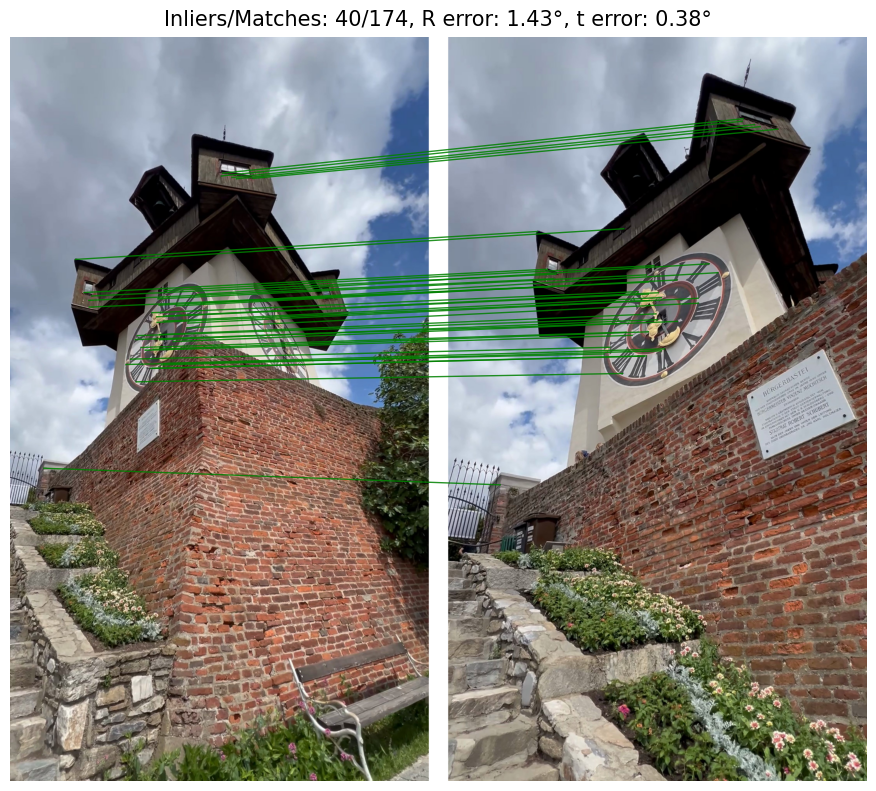

In [10]:
norm_threshold = 0.5 / (np.mean(np.abs(K_A[:2, :2])) + np.mean(np.abs(K_B[:2, :2])))
R_est, t_est, mask = estimate_pose(
    kpts1_matched, kpts2_matched,
    K_A, K_B, norm_threshold
)

pose_err = compute_pose_error(P, R_est, t_est)
plot_imgs_and_kpts(img_A.permute(1, 2, 0).cpu().numpy()*255, img_B.permute(1, 2, 0).cpu().numpy()*255, 
                kpts1_matched[mask], kpts2_matched[mask], # keeping only geometrically verified matches
                scatter=False, F_gt=F_gt, reth=5, figsize=(15, 8),
                highlight_bad_matches=False, 
                text=f'Inliers/Matches: {len(kpts1_matched[mask])}/{len(kpts1_matched)}, R error: {pose_err[0]:.2f}°, t error: {pose_err[1]:.2f}°',
                text_font=15)